# YOLOv8 Object Detection Pipeline — COCO128

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ares-infenus/yolov8-object-detection-pipeline/blob/main/notebooks/training_pipeline.ipynb)

Complete training, evaluation, inference, and export pipeline using YOLOv8n on COCO128.

**Requirements**: Google Colab with GPU runtime (Runtime > Change runtime type > T4 GPU)

## Phase 0: Environment Setup

In [1]:
# Mount Google Drive for persistence
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT = '/content/drive/MyDrive/proyecto_yolov8'
import os
os.makedirs(DRIVE_PROJECT, exist_ok=True)
print(f'Project dir: {DRIVE_PROJECT}')

Mounted at /content/drive
Project dir: /content/drive/MyDrive/proyecto_yolov8


In [2]:
# Install dependencies
!pip install -q ultralytics opencv-python-headless onnx onnxruntime matplotlib seaborn pyyaml

# Verify GPU
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.4 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# Clone repo (if running from Colab)
!git clone https://github.com/Ares-infenus/yolov8-object-detection-pipeline.git 2>/dev/null || echo 'Repo already cloned'
%cd yolov8-object-detection-pipeline

# Run setup verifier
!python scripts/fase0_setup_verificar.py

/content/yolov8-object-detection-pipeline
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{
  "fase": 0,
  "nombre": "setup",
  "checks": {
    "python_version": {
      "value": "3.12.12",
      "ok": true
    },
    "import_ultralytics": {
      "ok": true
    },
    "import_cv2": {
      "ok": true
    },
    "import_torch": {
      "ok": true
    },
    "import_onnx": {
      "ok": true
    },
    "import_matplotlib": {
      "ok": true
    },
    "import_yaml": {
      "ok": true
    },
    "gpu": {
      "available": true,
      "name": "Tesla T4",
      "ok": true
    },
    "git": {
      "available": true,
      "ok": true
    }
  },
  "status": "PASS"
}


## Phase 1: Data Preparation

In [4]:
# Download COCO128 dataset
!python scripts/download_dataset.py

# Download pre-trained weights
!python scripts/download_weights.py

# Download test video
!python scripts/download_test_video.py

# Verify data
!python scripts/fase1_datos_verificar.py


WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/yolov8-object-detection-pipeline/datasets/coco128/images/train2017'
Unzipping /content/yolov8-object-detection-pipeline/datasets/coco128.zip to /content/yolov8-object-detection-pipeline/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 688.6files/s 0.4s
Dataset download success ✅ (0.8s), saved to /content/yolov8-object-detection-pipeline/datasets

✅ Dataset ready at: /content/yolov8-object-detection-pipeline/datasets/coco128
   Classes: 80
   Train images: /content/yolov8-object-detection-pipeline/datasets/coco128/images/train2017
✅ Weights saved to: models/yolov8n.pt
Trying: https://github.com/ultralytics/assets/releases/download/v0.0.0/decelera_portrait_min.mov...
✅ Video saved: data/test_videos/sample.mp4 (0.6 MB)
{
  "fase": 1,
  "nombre": "datos",
  "checks": {
    "config_exists": {
      "ok": true
    },
    "dataset_downloaded": {
      "ok": true,
      "path": "datasets/coco128"
    },
    "image_count"

## Phase 2: Training

In [5]:
from ultralytics import YOLO

# Load pre-trained YOLOv8n
model = YOLO('models/yolov8n.pt')

# Train on COCO128
results = model.train(
    data='coco128.yaml',
    epochs=50,
    imgsz=640,
    batch=16,       # Reduce to 8 if OOM
    name='train',
    exist_ok=True,
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

In [6]:
# Verify training
!python scripts/fase2_entrenamiento_verificar.py

# Save checkpoint to Drive
import shutil
from pathlib import Path

# Find the actual training output directory
train_dir = None
for candidate in sorted(Path('.').rglob('best.pt')):
    train_dir = candidate.parent.parent  # weights/best.pt -> train dir
    break

if train_dir and train_dir.exists():
    dst = f'{DRIVE_PROJECT}/runs/detect/train'
    shutil.copytree(str(train_dir), dst, dirs_exist_ok=True)
    print(f'Checkpoint saved to Drive from: {train_dir}')
else:
    print('⚠️  No training output found yet. Check that Phase 2 training completed.')

{
  "fase": 2,
  "nombre": "entrenamiento",
  "checks": {
    "train_dir_exists": {
      "ok": true,
      "path": "runs/detect/train"
    },
    "best_weights": {
      "ok": true,
      "path": "runs/detect/train/weights/best.pt"
    },
    "last_weights": {
      "ok": true,
      "path": "runs/detect/train/weights/last.pt"
    },
    "results_csv": {
      "ok": true
    },
    "results_plot": {
      "ok": true
    },
    "confusion_matrix": {
      "ok": true
    },
    "weights_size_mb": {
      "value": 6.24,
      "ok": true
    }
  },
  "status": "PASS"
}
Checkpoint saved to Drive from: runs/detect/train


## Phase 3: Evaluation

In [7]:
!python src/evaluate.py
!python scripts/fase3_evaluacion_verificar.py

Evaluating base model: models/yolov8n.pt
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2310.3±450.3 MB/s, size: 82.9 KB)
val: Scanning /content/yolov8-object-detection-pipeline/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 31.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.2it/s 2.5s
                   all        128        929      0.639      0.536      0.607      0.448
Speed: 2.4ms preprocess, 5.9ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/yolov8-object-detection-pipeline/runs/detect/val
  Base mAP@50: 0.6072
Evaluating trained model: runs/detect/train/weights/best.pt
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913M

## Phase 4: Inference + Speed Benchmark

In [8]:
!python src/inference.py
!python scripts/fase4_inferencia_verificar.py

Running inference on 3 sample images...

0: 640x640 3 bowls, 6 oranges, 1 broccoli, 17.2ms
1: 640x640 2 giraffes, 17.2ms
2: 640x640 1 potted plant, 1 vase, 17.2ms
Speed: 2.9ms preprocess, 17.2ms inference, 6.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/yolov8-object-detection-pipeline/runs/detect/predict
  Saved: results/samples/detection_sample_1.jpg
  Saved: results/samples/detection_sample_2.jpg
  Saved: results/samples/detection_sample_3.jpg
Running speed benchmark (100 iterations)...
✅ Speed benchmark saved to: results/metrics/speed_benchmark.json
   FPS: 126.49 | Latency: 7.91ms
{
  "fase": 4,
  "nombre": "inferencia",
  "checks": {
    "speed_benchmark": {
      "ok": true
    },
    "fps_measured": {
      "ok": true,
      "value": 126.49
    },
    "latency_measured": {
      "ok": true,
      "value": 7.91
    },
    "sample_images": {
      "count": 3,
      "ok": true
    }
  },
  "status": "PASS"
}



detection_sample_1.jpg


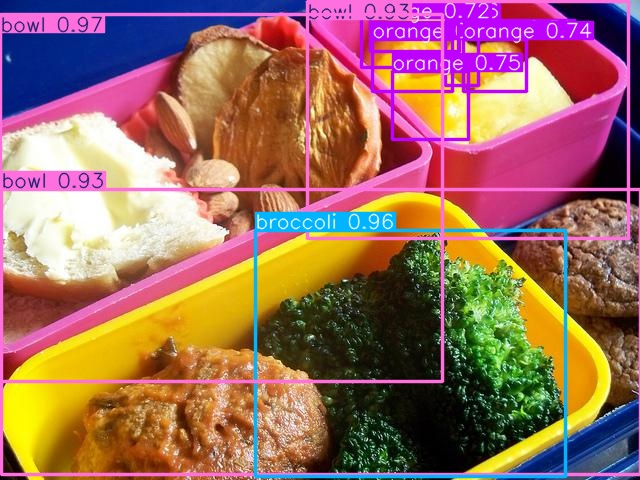


detection_sample_2.jpg


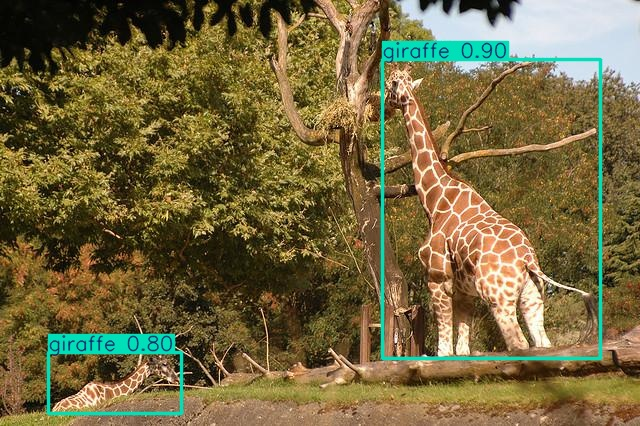


detection_sample_3.jpg


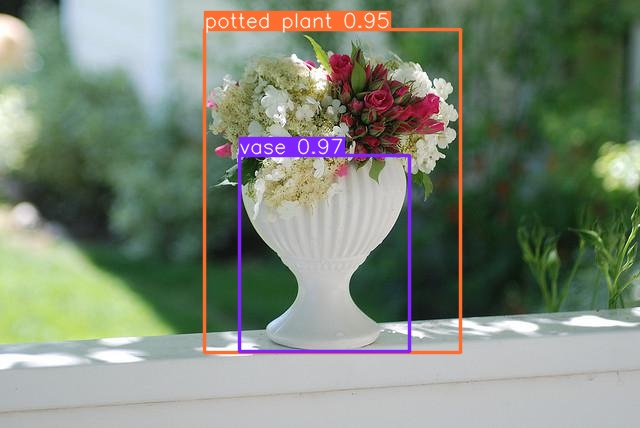

In [9]:
# Display sample detections
from IPython.display import Image, display
from pathlib import Path

for img in sorted(Path('results/samples').glob('*.jpg')):
    print(f'\n{img.name}')
    display(Image(filename=str(img), width=500))

## Phase 5: ONNX Export

In [10]:
!python src/export.py
!python scripts/fase5_exportacion_verificar.py

Exporting runs/detect/train/weights/best.pt to ONNX...
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 10 packages in 221ms
Prepared 2 packages in 43ms
Installed 2 packages in 8ms
 + colorama==0.4.6
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export su

## Phase 6: Demo Video

In [11]:
!python src/demo_video.py
!python scripts/fase6_demo_verificar.py

Generating demo video...
  Model: runs/detect/train/weights/best.pt
  Input: data/test_videos/sample.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/11) /content/yolov8-object-detection-pipeline/data/test_videos/sample.mp4: 640x384 3 persons, 50.6ms
video 1/1 (frame 2/11) /content/yolov8-object-detection-pipeline/data/test_videos/sample.mp4: 640x384 4 persons, 10.2ms
video 1/1 (frame 3/11) /content/yolov8-object-detection-pipeline/data/test_videos/sample.mp4: 640x384 3 persons, 

## Generate Executive Report

In [12]:
!python scripts/generate_executive_report.py

✅ Generated: docs/images/results_chart.png
/content/yolov8-object-detection-pipeline/scripts/generate_executive_report.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'{output_dir}/executive_summary.png', dpi=150,
✅ Generated: docs/images/executive_summary.png


## General Health Check

In [13]:
!python scripts/comprobador_general.py

  COMPROBADOR GENERAL — YOLOv8 Pipeline Health Check

  ✅ Fase 0: Setup: PASS
  ✅ Fase 1: Datos: PASS
  ✅ Fase 2: Entrenamiento: PASS
  ✅ Fase 3: Evaluacion: PASS
  ✅ Fase 4: Inferencia: PASS
  ✅ Fase 5: Exportacion: PASS
  ✅ Fase 6: Demo: PASS

  ✅ RESULTADO: COMPLETO — Todas las fases aprobadas


## Save All Results to Drive

In [14]:
import shutil

# Save everything to Drive
for src_dir in ['results', 'docs/images', 'models']:
    dst = f'{DRIVE_PROJECT}/{src_dir}'
    if Path(src_dir).exists():
        shutil.copytree(src_dir, dst, dirs_exist_ok=True)
        print(f'Saved {src_dir} -> {dst}')

print('\nAll results saved to Google Drive!')

Saved results -> /content/drive/MyDrive/proyecto_yolov8/results
Saved docs/images -> /content/drive/MyDrive/proyecto_yolov8/docs/images
Saved models -> /content/drive/MyDrive/proyecto_yolov8/models

All results saved to Google Drive!


In [21]:
# Comprimir todo lo que necesitas subir
!zip -r resultados.zip results/samples/ results/metrics/ docs/images/


updating: results/samples/ (stored 0%)
updating: results/samples/detection_sample_1.jpg (deflated 3%)
updating: results/samples/detection_sample_2.jpg (deflated 5%)
updating: results/samples/detection_sample_3.jpg (deflated 4%)
updating: results/metrics/ (stored 0%)
updating: results/metrics/training_summary.json (deflated 29%)
updating: results/metrics/comparison_base_vs_trained.json (deflated 47%)
updating: results/metrics/speed_benchmark.json (deflated 37%)
updating: docs/images/ (stored 0%)
updating: docs/images/results_chart.png (deflated 14%)
updating: docs/images/confusion_matrix.png (deflated 21%)
updating: docs/images/executive_summary.png (deflated 8%)
updating: docs/images/training_curves.png (deflated 7%)
